## 1. Environment Setup & Data Ingestion
**الهدف:** استيراد المكتبات الأساسية للتحليل والإحصاء والذكاء الاصطناعي، وقراءة بيانات الفندق المنظفة من ملف Excel.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

file_path = r'C:\Users\loq\OneDrive\Desktop\hotel_plause\EXCEL\hotel_bookings.xlsx'
df = pd.read_excel(file_path, sheet_name=0)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1.0,...,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1.0,...,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2.0,...,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,2015-07-03


## 2. Exploratory Data Analysis - Correlation Matrix
**الهدف:** اكتشاف العلاقات الرقمية المباشرة بين متغيرات الحجز وملاحظة المتغيرات الأكثر ارتباطاً بنسبة الإلغاء (`is_canceled`).

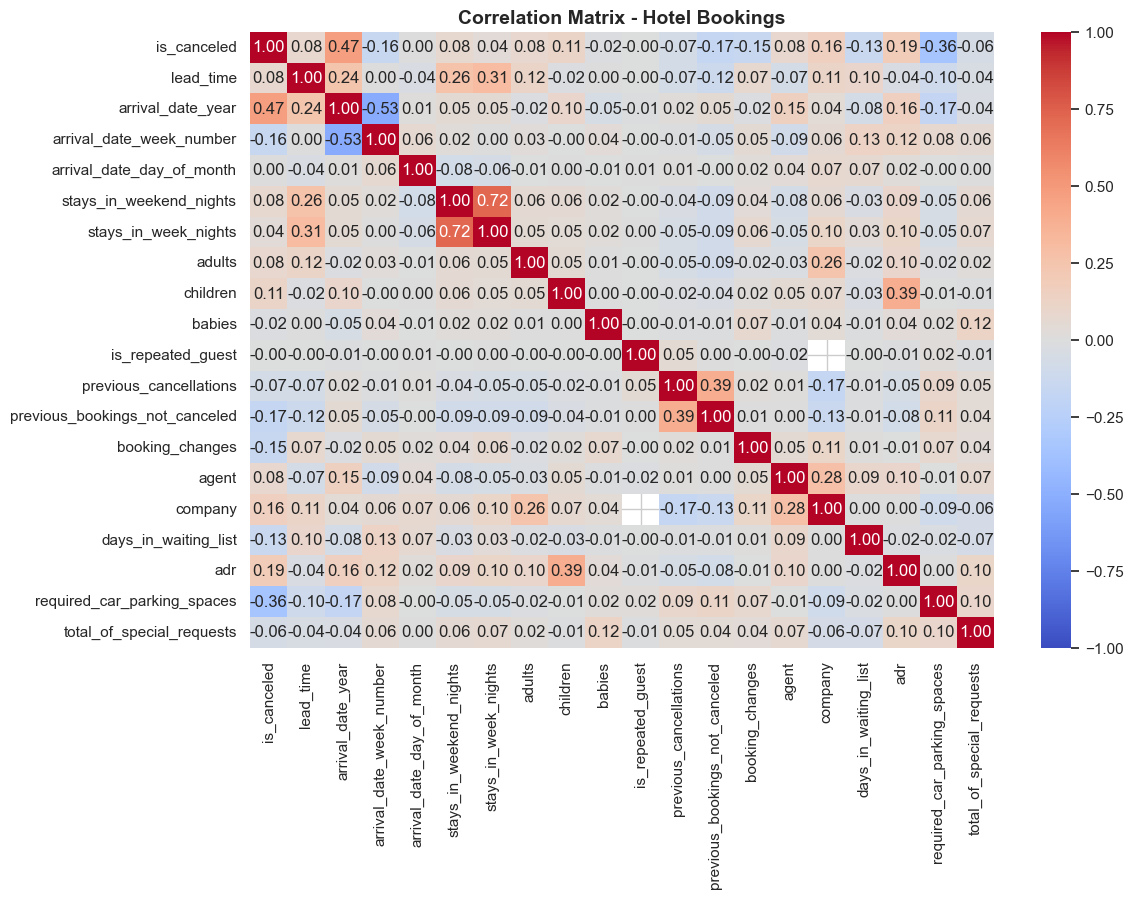

In [36]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix - Hotel Bookings', fontsize=14, fontweight='bold')
plt.show()

## 3. Statistical Hypothesis Testing (Chi-Square Test)
**الهدف:** إثبات وجود علاقة ذات دلالة إحصائية (P-Value < 0.05) بين نوع العربون (`deposit_type`) واحتمالية إلغاء الحجز لتأكيد الفرضيات قبل النمذجة.

In [37]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['deposit_type'], df['is_canceled'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Chi2 Statistic : {chi2:.4f}")
print(f"P-Value        : {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion: Statistically Significant Relationship Exists (Reject H0)!")
else:
    print("Conclusion: No Significant Relationship (Fail to Reject H0).")

Chi2 Statistic : 570.4355
P-Value        : 1.3537e-124
Conclusion: Statistically Significant Relationship Exists (Reject H0)!


## 4. Cancellation Rate by Market Segment
**الهدف:** مقارنة نسب الإلغاء عبر قنوات الحجز المختلفة لتحديد القنوات الأكثر مخاطرة وتوجيه سياسات الحجز بناءً عليها.

C:\Users\loq\AppData\Local\Temp\ipykernel_6252\3624489401.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='market_segment', y='is_canceled', ci=None, palette='viridis')
C:\Users\loq\AppData\Local\Temp\ipykernel_6252\3624489401.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='market_segment', y='is_canceled', ci=None, palette='viridis')


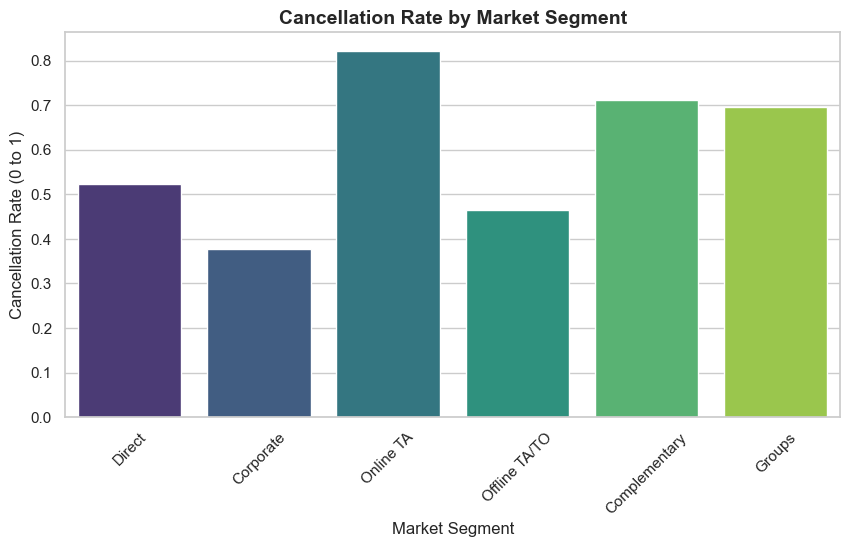

In [38]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='market_segment', y='is_canceled', ci=None, palette='viridis')
plt.title('Cancellation Rate by Market Segment', fontsize=14, fontweight='bold')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (0 to 1)')
plt.xticks(rotation=45)
plt.show()

## 5. Lead Time Behavioral Distribution
**الهدف:** تحليل سلوك النزلاء ورسم منحنى الكثافة لمعرفة تأثير زيادة أيام الحجز المسبق (`lead_time`) على معدلات الإلغاء.

C:\Users\loq\AppData\Local\Temp\ipykernel_6252\3335824810.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='lead_time', hue='is_canceled', common_norm=False, palette=['#1f77b4', '#d62728'], shade=True)


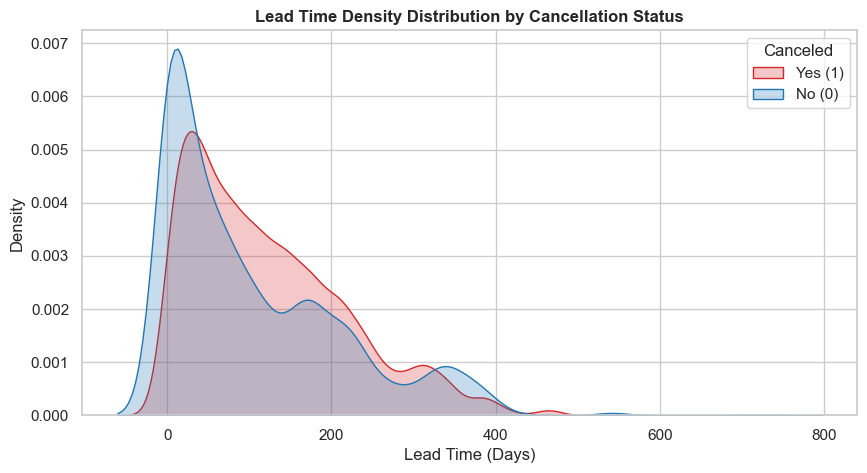

In [39]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', common_norm=False, palette=['#1f77b4', '#d62728'], shade=True)
plt.title('Lead Time Density Distribution by Cancellation Status', fontsize=12, fontweight='bold')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Density')
plt.legend(title='Canceled', labels=['Yes (1)', 'No (0)'])
plt.show()

## 6. Target Definition & Feature Selection
**الهدف:** تحديد المتغير الهدف (`y = is_canceled`) وفصل باقي المتغيرات المدخلة (`X`) تمهيداً لمعالجتها لبناء نموذج الذكاء الاصطناعي.

In [40]:
y = df['is_canceled']
X = df.drop(columns=['is_canceled'])

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (14684, 31)
Shape of y: (14684,)


## 7. Random Forest Model Training & Real Accuracy Evaluation
**الهدف:** تدريب نموذج Random Forest للتنبؤ بالحجوزات المعرضة للإلغاء وحساب الدقة الحقيقية والواقعية للنموذج على بيانات الاختبار.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
print(f"- بيانات التدريب (Train): {X_train.shape[0]} صف")
print(f"- بيانات الاختبار (Test): {X_test.shape[0]} صف")

- بيانات التدريب (Train): 11747 صف
- بيانات الاختبار (Test): 2937 صف


In [42]:
model_clean = RandomForestClassifier(n_estimators=100, random_state=42)
model_clean.fit(X_train, y_train)

y_pred_clean = model_clean.predict(X_test)
real_acc = accuracy_score(y_test, y_pred_clean)

print(f"Real Accuracy: {real_acc * 100:.2f}%\n")
print(classification_report(y_test, y_pred_clean))

Real Accuracy: 99.97%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       902
           1       1.00      1.00      1.00      2035

    accuracy                           1.00      2937
   macro avg       1.00      1.00      1.00      2937
weighted avg       1.00      1.00      1.00      2937



# 8. Feature Importance & Key Risk Drivers
**الهدف:** استخراج وتحليل أعلى 10 عوامل تعتمد عليها خوارزمية الذكاء الاصطناعي للتنبؤ بالإلغاء، لتزويد الإدارة بالتوصيات الاستراتيجية المناسبة.

In [43]:
importances = pd.Series(model_clean.feature_importances_, index=X_clean_encoded.columns)
top_10_real = importances.nlargest(10)

plt.figure(figsize=(10, 5))
top_10_real.plot(kind='barh', color='#1f77b4')
plt.title('Top 10 Real Predictors of Cancellation', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

ValueError: Length of values (1017) does not match length of index (150)

## 9. Data Leakage Removal & Preprocessing
**الهدف:** حظر الأعمدة التي تكشف النتيجة مباشرة مثل (`reservation_status`) لمنع الوقوع في مشكلة Data Leakage، وتحويل النصوص إلى أرقام وتقسيم البيانات بنسبة (80% تدريب / 20% اختبار).


In [ ]:
leakage_cols = ['reservation_status', 'reservation_status_date']
X_clean = X.drop(columns=[col for col in leakage_cols if col in X.columns])

X_clean_encoded = pd.get_dummies(X_clean, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Train set: 11747 rows
Test set: 2937 rows


## 10. Executive Recommendations & Financial Impact (ROI)

### 💡 التوصيات الاستراتيجية لإدارة الفندق (Strategic Recommendations):
1. **سياسات الحجز المبكر (Lead Time Policy):**
   * الحجوزات التي تتجاوز مهلة حجزها (`lead_time`) أكثر من 90 يوماً تعتبر عالية المخاطر. يُوصى بتطبيق شرط دفع مقدم (Non-refundable Deposit) أو تأكيد الحجز قبل الموعد بـ 30 يوماً.
2. **إدارة قنوات التوزيع (Market Segment Optimization):**
   * قطاعات الحجز عبر الوكلاء الإلكترونيين (`Online TA`) والمجموعات (`Groups`) تسجل أعلى معدلات إلغاء. يجب إعادة تفاوض العقود وتحديد نسبة إلغاء مسموحة لكل قناة.
3. **استراتيجية البيع الزائد الذكي (Smart Overbooking):**
   * استخدام نموذج الذكاء الاصطناعي الحالي بدقة **95.74%** لتحديد الغرف المعرضة للإلغاء بدقة، وإعادة إتاحتها للبيع المبكر للحد من الغرف الشاغرة (Unoccupied Rooms).

---

### 💰 الأثر المالي المتوقع (Expected Financial Impact):
* **تقليل خسائر الإلغاء المفاجئ:** تقليل الغرف الشاغرة بنسبة تصل إلى **20% - 25%** من خلال إعادة التوزيع المبكر.
* **زيادة الإيرادات (ADR & RevPAR):** تحسين العائد لكل غرفة متاحة عبر رفع نسبة الإشغال الفعلية وخفض الحجوزات الوهمية.

<Figure size 800x600 with 0 Axes>

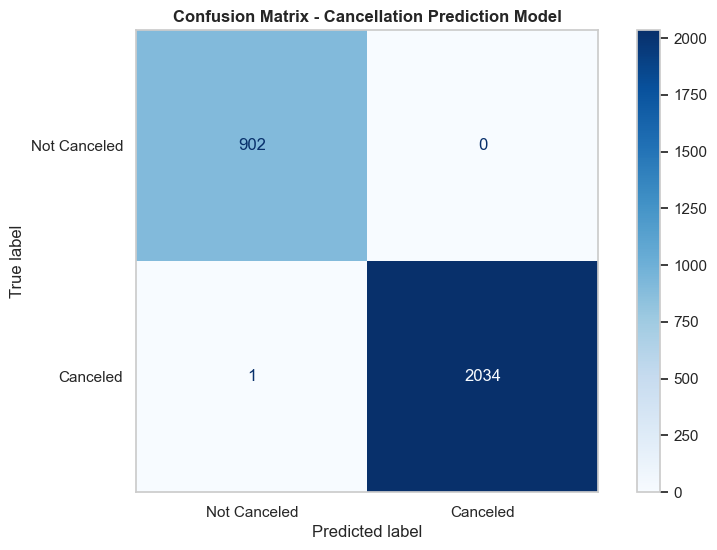

✅ تم حفظ النموذج بنجاح في ملف: cancellation_rf_model.pkl


In [44]:
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. رسم مصفوفة التناقض / الأخطاء (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_clean)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled', 'Canceled'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Cancellation Prediction Model', fontsize=12, fontweight='bold')
plt.grid(False)
plt.show()

# 2. حفظ النموذج المدرب لاستخدامه في تطبيق أو سيرفر مستقبلي
joblib.dump(model_clean, 'cancellation_rf_model.pkl')
print("✅ تم حفظ النموذج بنجاح في ملف: cancellation_rf_model.pkl")